<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_Learning_Techniques_Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

# Lab 10: End-to-End Machine Learning Pipeline for Cloud Infrastructure Failure Prediction


### Aim

To design and implement a complete machine learning pipeline capable of predicting cloud infrastructure failures using real-world monitoring datasets by integrating data preprocessing, feature engineering, feature selection, model development, evaluation, visualization, and model persistence.

### Objectives

- Load and preprocess multiple cloud infrastructure datasets.
- Perform exploratory data analysis on raw monitoring data.
- Engineer meaningful features from timestamp-based records.
- Prepare a high-dimensional cloud infrastructure dataset for predictive modelling.
- Apply feature selection to identify the most informative cloud monitoring features.
- Train and evaluate a Random Forest classifier for multi-class cloud failure prediction.
- Visualize the complete machine learning workflow through meaningful analytical plots.
- Save and reload the trained model for future predictions.

## Machine Learning Pipeline Overview

This experiment integrates all stages of a real-world machine learning workflow.


```
                 DATASET A
        (Raw Monitoring Dataset)
                     │
                     ▼
          Data Preprocessing
                     │
                     ▼
         Feature Engineering
                     │
                     ▼
          Exploratory Analysis
                     │
                     │
                     ▼
                 DATASET B
      (Engineered Feature Dataset)
                     │
                     ▼
            Feature Selection
                     │
                     ▼
         Random Forest Training
                     │
                     ▼
            Model Evaluation
                     │
                     ▼
           Model Persistence
                     │
                     ▼
          Prediction on New Data
```

## Importing Required Libraries

The following libraries provide support for data preprocessing, visualization, feature engineering, feature selection, model training, evaluation, and model persistence throughout the machine learning pipeline.

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    SelectKBest,
    f_classif
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("dark_background")

plt.rcParams.update({

    "figure.figsize":(10,6),

    "axes.facecolor":"black",

    "figure.facecolor":"black",

    "savefig.facecolor":"black",

    "axes.edgecolor":"white",

    "axes.labelcolor":"white",

    "axes.titlecolor":"orange",

    "xtick.color":"white",

    "ytick.color":"white",

    "grid.color":"gray",

    "font.size":11,

    "axes.grid":True

})

PRIMARY_COLOR = "orange"
SECONDARY_COLOR = "gold"

print("All libraries imported successfully.")

All libraries imported successfully.


## Uploading Cloud Infrastructure Datasets

Both datasets are uploaded as part of the end-to-end machine learning pipeline.

- **Dataset A** demonstrates preprocessing, exploratory analysis, and feature engineering.
- **Dataset B** contains engineered cloud infrastructure features used for predictive modelling.

In [ ]:
uploaded = files.upload()

Saving CIFPS - DATASET A.zip to CIFPS - DATASET A.zip
Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

for file in uploaded_files:

    with zipfile.ZipFile(file,"r") as zip_ref:

        zip_ref.extractall()

print("Datasets extracted successfully.")

print("\nUploaded Files:\n")

for file in uploaded_files:

    print(file)

Datasets extracted successfully.

Uploaded Files:

CIFPS - DATASET A.zip
CIFPS - DATASET B.zip


## Project Workspace Verification

Before beginning data analysis, the working directory is verified to ensure that both cloud infrastructure datasets have been extracted successfully and are available for subsequent stages of the machine learning pipeline.

In [ ]:
all_files=[]

for root,dirs,files in os.walk("."):

    for file in files:

        all_files.append(
            os.path.join(root,file)
        )

workspace=pd.DataFrame({

    "Available Files":sorted(all_files)

})

display(workspace)

,Available Files
0,./.config/.last_opt_in_prompt.yaml
1,./.config/.last_survey_prompt.yaml
2,./.config/.last_update_check.json
3,./.config/active_config
4,./.config/config_sentinel
...,...
154,./sample_data/anscombe.json
155,./sample_data/california_housing_test.csv
156,./sample_data/california_housing_train.csv
157,./sample_data/mnist_test.csv


## Project Structure Summary

The following summary provides an overview of the extracted project resources before beginning data preprocessing.

In [ ]:
summary=pd.DataFrame({

    "Component":[

        "Dataset A",

        "Dataset B",

        "Total Files"

    ],

    "Status":[

        "Available",

        "Available",

        len(workspace)

    ]

})

display(summary)

,Component,Status
0,Dataset A,Available
1,Dataset B,Available
2,Total Files,159


## Phase 2: Data Acquisition and Preprocessing

The first stage of any machine learning pipeline involves understanding and preparing the raw data. Dataset A contains timestamp-based cloud monitoring records, making it suitable for exploratory analysis, data cleaning, timestamp processing, and feature engineering before predictive modelling.

## Loading Dataset A

The raw cloud monitoring dataset is loaded into the notebook for exploratory analysis and preprocessing. This dataset serves as the foundation for understanding the operational behaviour of cloud infrastructure before advanced machine learning techniques are applied.

In [ ]:
data_dir = "/content/cloud-monitoring-dataset-master/data/"
all_dataframes = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            try:
                df = pd.read_csv(file_path)
                all_dataframes.append(df)
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

if all_dataframes:
    dataset_a = pd.concat(all_dataframes, ignore_index=True)
    print("Dataset A Loaded Successfully and concatenated from multiple CSVs.\n")
    display(dataset_a.head())
else:
    print("No CSV files found or processed in Dataset A directories.")

Dataset A Loaded Successfully and concatenated from multiple CSVs.



,TimeStamp,Value,Label
0,2018-07-03 14:00:00,1.0,0
1,2018-07-03 15:00:00,0.0,0
2,2018-07-03 16:00:00,1.0,0
3,2018-07-03 17:00:00,1.0,0
4,2018-07-03 18:00:00,0.0,0


## Dataset Overview

The dataset is examined to understand its dimensions, feature names, data types, and descriptive statistics. This initial inspection helps identify the overall structure of the cloud monitoring data before preprocessing.

In [ ]:
print("Shape of Dataset A :", dataset_a.shape)

print("\nColumn Names\n")

display(
    pd.DataFrame(
        dataset_a.columns,
        columns=["Columns"]
    )
)

print("\nData Types\n")

display(dataset_a.dtypes)

print("\nSummary Statistics\n")

display(dataset_a.describe(include="all"))

Shape of Dataset A : (225445, 3)

Column Names



,Columns
0,TimeStamp
1,Value
2,Label



Data Types



,0
TimeStamp,object
Value,float64
Label,int64



Summary Statistics



,TimeStamp,Value,Label
count,225445,2.254030e+05,225445.000000
unique,43248,NaN,NaN
top,2018-06-21 01:00:00,NaN,NaN
freq,27,NaN,NaN
mean,NaN,1.976605e+05,0.020204
std,NaN,4.763119e+05,0.140700
min,NaN,0.000000e+00,0.000000
25%,NaN,3.989399e+01,0.000000
50%,NaN,4.690000e+02,0.000000
75%,NaN,1.285771e+05,0.000000


## Missing Value Analysis

Missing value analysis is an important preprocessing step that helps identify incomplete observations. Detecting missing values early ensures the reliability of subsequent feature engineering and predictive modelling.

In [ ]:
missing_values = dataset_a.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values
})

display(missing_df)

,Column,Missing Values
0,TimeStamp,0
1,Value,42
2,Label,0


## Visualization 1: Missing Value Heatmap

The following heatmap visually highlights the presence or absence of missing values across the raw cloud monitoring dataset.

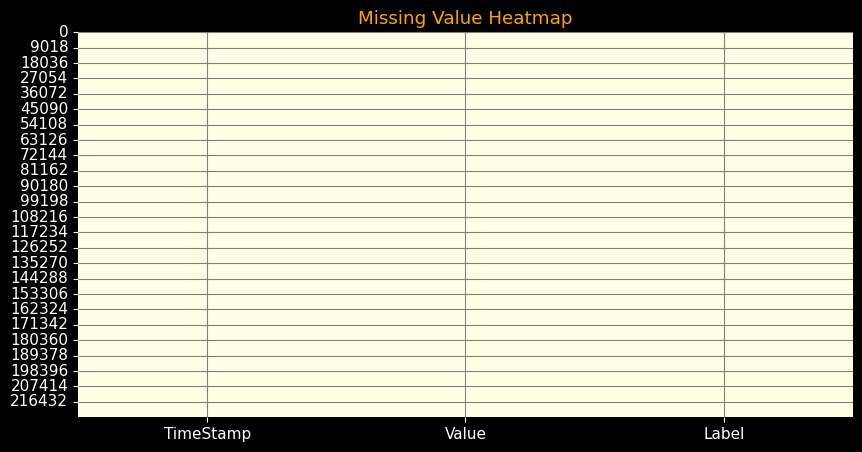

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    dataset_a.isnull(),
    cbar=False,
    cmap="YlOrBr"
)

plt.title("Missing Value Heatmap", color="orange")

plt.show()

## Timestamp Processing and Feature Engineering

Timestamp information is converted into a datetime format to extract useful temporal features such as the monitoring hour, day, month, and day of the week. These engineered features help uncover operational patterns within the cloud monitoring data.

In [ ]:
dataset_a["TimeStamp"] = pd.to_datetime(
    dataset_a["TimeStamp"], format='mixed', errors='coerce', utc=True
)

dataset_a["Hour"] = dataset_a["TimeStamp"].dt.hour

dataset_a["Day"] = dataset_a["TimeStamp"].dt.day

dataset_a["Month"] = dataset_a["TimeStamp"].dt.month

dataset_a["DayOfWeek"] = dataset_a["TimeStamp"].dt.day_name()

print("Feature Engineering Completed.\n")

display(dataset_a.head())

Feature Engineering Completed.



,TimeStamp,Value,Label,Hour,Day,Month,DayOfWeek
0,2018-07-03 14:00:00+00:00,1.0,0,14,3,7,Tuesday
1,2018-07-03 15:00:00+00:00,0.0,0,15,3,7,Tuesday
2,2018-07-03 16:00:00+00:00,1.0,0,16,3,7,Tuesday
3,2018-07-03 17:00:00+00:00,1.0,0,17,3,7,Tuesday
4,2018-07-03 18:00:00+00:00,0.0,0,18,3,7,Tuesday


## Visualization 2: Time Series of Cloud Monitoring Values

The following time-series plot illustrates how the monitored cloud infrastructure values change over time. Such visualizations are useful for identifying operational trends and sudden fluctuations in monitoring behaviour.

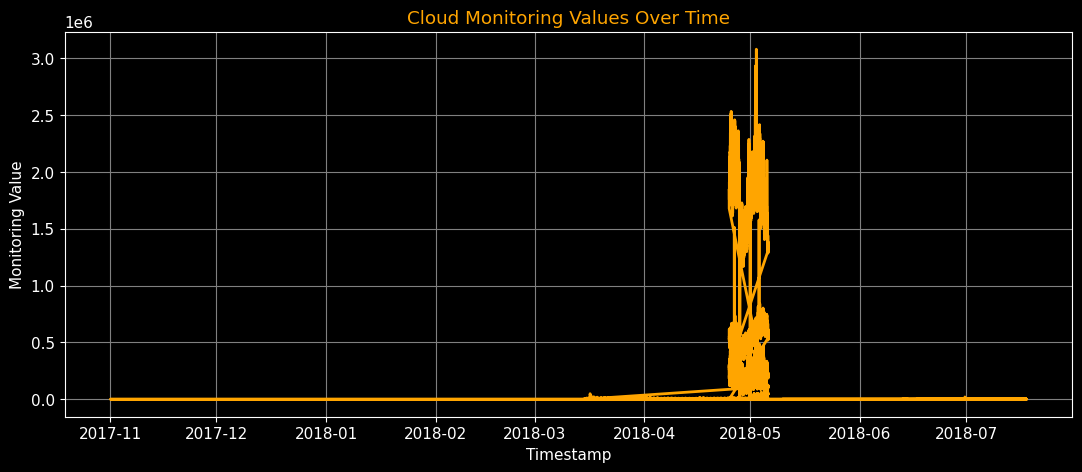

In [ ]:
plt.figure(figsize=(13,5))

plt.plot(
    dataset_a["TimeStamp"],
    dataset_a["Value"],
    color="orange",
    linewidth=2
)

plt.title("Cloud Monitoring Values Over Time")

plt.xlabel("Timestamp")

plt.ylabel("Monitoring Value")

plt.show()

## Visualization 3: Hour-wise Monitoring Activity

The following visualization summarizes the average monitoring value observed during different hours of the day, helping identify periods of increased cloud infrastructure activity.

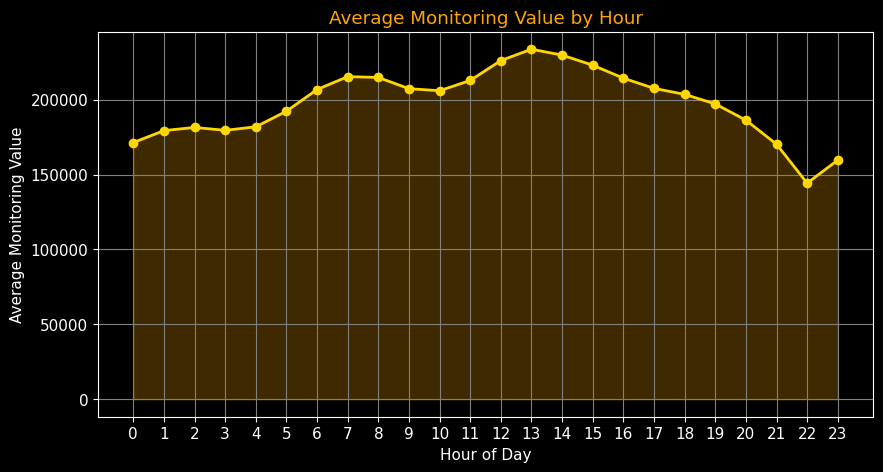

In [ ]:
hourly = dataset_a.groupby(
    "Hour"
)["Value"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    hourly.index,
    hourly.values,
    marker="o",
    linewidth=2,
    color="gold"
)

plt.fill_between(
    hourly.index,
    hourly.values,
    color="orange",
    alpha=0.25
)

plt.title("Average Monitoring Value by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Monitoring Value")

plt.xticks(range(24))

plt.show()

# Phase 3: Machine Learning Model Development

The preprocessing stage has transformed the raw monitoring dataset into meaningful information. In this phase, an engineered cloud infrastructure dataset is used to develop a predictive machine learning model capable of identifying different cloud infrastructure failure categories.

## Loading Dataset B

Dataset B contains engineered cloud infrastructure monitoring features extracted from OpenStack deployment logs. Unlike Dataset A, this dataset has already undergone feature engineering and is therefore suitable for predictive modelling.

In [ ]:
DATASET_B_PATH = "Failure-Dataset-OpenStack-main"

feature_file = os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "LCS_with_VMM.tsv"
)

label_file = os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "Failure_Labels.txt"
)

X = pd.read_csv(
    feature_file,
    sep="\t"
)

labels = pd.read_csv(
    label_file,
    header=None,
    names=["Label"]
)

model_df = X.copy()

model_df["Label"] = labels["Label"]

print("Dataset B Loaded Successfully.")

display(model_df.head())

Dataset B Loaded Successfully.


,cinderclient_DELETE_202,cinderclient_DELETE_400,cinderclient_DELETE_500,cinderclient_GET_200,cinderclient_GET_400,cinderclient_GET_404,cinderclient_GET_500,cinderclient_POST_200,cinderclient_POST_202,cinderclient_POST_400,...,q-plugin_release_dhcp_port.1,q-plugin_update_device_list.1,q-plugin_update_device_list_ERROR.1,scheduler_delete_instance_info.1,scheduler_delete_instance_info_ERROR.1,scheduler_select_destinations.1,scheduler_select_destinations_ERROR.1,scheduler_update_instance_info.1,scheduler_update_instance_info_ERROR.1,Label
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6


## Dataset B Overview

The engineered dataset consists of cloud infrastructure operational features together with their corresponding failure classes. These features serve as the input variables for predictive modelling.

In [ ]:
summary = pd.DataFrame({

    "Property":[

        "Number of Records",

        "Number of Features",

        "Failure Classes"

    ],

    "Value":[

        model_df.shape[0],

        model_df.shape[1]-1,

        model_df["Label"].nunique()

    ]

})

display(summary)

display(
    model_df["Label"]
    .value_counts()
    .sort_index()
)

,Property,Value
0,Number of Records,1076
1,Number of Features,208
2,Failure Classes,6


,count
Label,
1,224
2,151
3,41
4,69
5,52
6,539


## Visualization 4: Failure Class Distribution

The following chart illustrates the distribution of cloud infrastructure failure categories present in the engineered dataset. Understanding the class distribution is important before training predictive models.

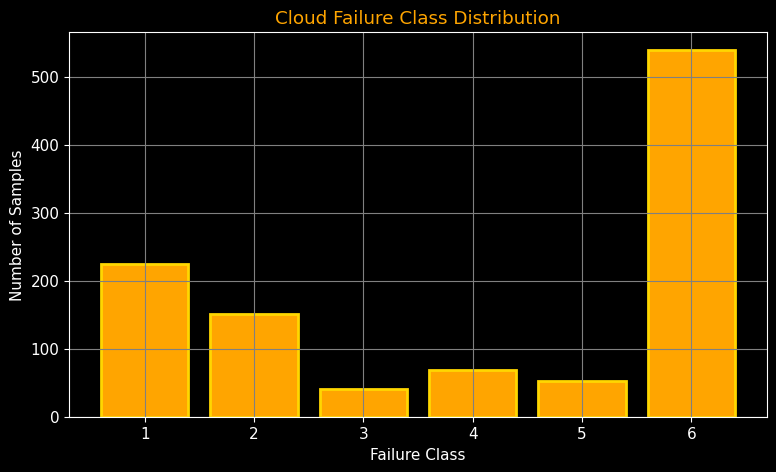

In [ ]:
class_distribution = (
    model_df["Label"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9,5))

plt.bar(
    class_distribution.index.astype(str),
    class_distribution.values,
    color="orange",
    edgecolor="gold",
    linewidth=2
)

plt.title("Cloud Failure Class Distribution")

plt.xlabel("Failure Class")

plt.ylabel("Number of Samples")

plt.show()

## Feature Selection

Although the dataset contains more than two hundred engineered cloud monitoring features, not every feature contributes equally to prediction. ANOVA-based feature selection is applied to retain only the most informative features before model training.

In [ ]:
X = model_df.drop(
    columns=["Label"]
)

y = model_df["Label"]

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_selected = selector.fit_transform(
    X,
    y
)

selected_features = X.columns[
    selector.get_support()
]

feature_scores = pd.DataFrame({

    "Feature": selected_features,

    "Score": selector.scores_[selector.get_support()]

})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

print("Original Features :", X.shape[1])

print("Selected Features :", X_selected.shape[1])

display(feature_scores.head(20))

Original Features : 208
Selected Features : 50


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  0   5   7  14  16  18  20  22  26  27  29  30  31  35  37  43  49  51
  55  58  59  80  94 102 105 106 108 109 110 113 114 115 117 119 121 123
 125 127 129 136 138 140 144 150 157 161 162 164 166 168 171 172 173 174
 175 177 180 183 187 190 192 195 197 201 203 205 206 207] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Feature,Score
19,compute_reboot_instance.1,4834.511317
11,cinder-volume.localhost.localdomain@lvm_attach...,3382.139692
21,compute_terminate_instance.1,2833.432784
28,l3_agent_routers_updated.1,2697.710689
42,q-l3-plugin_sync_routers.1,2327.705705
35,novaclient_POST_200.1,1630.956493
20,compute_reserve_block_device_name.1,1412.319543
27,ipsec_driver_get_vpn_services_on_host.1,1393.318211
14,cinder-volume.localhost.localdomain@lvm_initia...,1244.866518
9,cinderclient_POST_200.1,1244.866518


## Visualization 5: Top Feature Scores

The following visualization presents the twenty most informative cloud monitoring features selected using ANOVA feature selection. Higher scores indicate stronger discriminatory power for cloud failure classification.

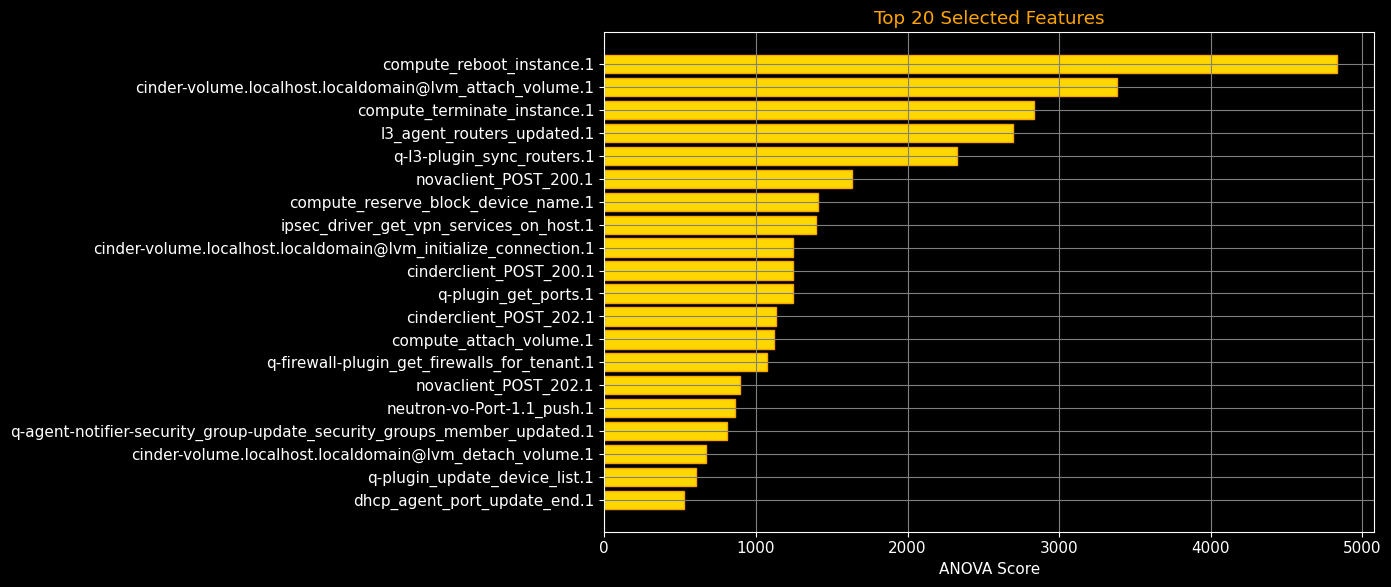

In [ ]:
top20 = feature_scores.head(20)

plt.figure(figsize=(14,6))

plt.barh(

    top20["Feature"],

    top20["Score"],

    color="gold",

    edgecolor="orange"

)

plt.gca().invert_yaxis()

plt.title("Top 20 Selected Features")

plt.xlabel("ANOVA Score")

plt.tight_layout()

plt.show()

## Preparing the Training and Testing Dataset

The selected features are divided into training and testing subsets. The Random Forest classifier will learn from the training data and its predictive performance will be evaluated using the testing data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X_selected,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

split_summary = pd.DataFrame({

    "Dataset":[

        "Training Samples",

        "Testing Samples",

        "Training Labels",

        "Testing Labels"

    ],

    "Shape":[

        X_train.shape,

        X_test.shape,

        y_train.shape,

        y_test.shape

    ]

})

display(split_summary)

,Dataset,Shape
0,Training Samples,"(860, 50)"
1,Testing Samples,"(216, 50)"
2,Training Labels,"(860,)"
3,Testing Labels,"(216,)"


## Training the Random Forest Classifier

Random Forest is selected as the final predictive model because it demonstrated strong performance on the engineered cloud infrastructure dataset. The classifier combines multiple decision trees to improve prediction accuracy and robustness.

In [ ]:
random_forest = RandomForestClassifier(

    n_estimators=100,

    random_state=42,

    oob_score=True

)

random_forest.fit(

    X_train,

    y_train

)

predictions = random_forest.predict(
    X_test
)

probabilities = random_forest.predict_proba(
    X_test
)

print("Random Forest Model Trained Successfully.\n")

print(f"Out-of-Bag Score : {random_forest.oob_score_:.4f}")

Random Forest Model Trained Successfully.

Out-of-Bag Score : 0.9523


## Phase 4: Model Evaluation and Performance Analysis

After training the Random Forest classifier, its predictive performance is evaluated using standard machine learning metrics. The trained model is then interpreted, saved for future use, and tested on unseen cloud infrastructure observations to complete the end-to-end machine learning pipeline.

## Model Evaluation

The Random Forest classifier is evaluated using Accuracy, Precision, Recall, and F1 Score. These metrics collectively measure the effectiveness of the model in predicting cloud infrastructure failure categories.

In [ ]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

evaluation = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]

})

evaluation["Score"] = evaluation["Score"].round(4)

display(evaluation)

print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)

,Metric,Score
0,Accuracy,0.9630
1,Precision,0.9655
2,Recall,0.9630
3,F1 Score,0.9611



Classification Report

              precision    recall  f1-score   support

           1       1.00      0.98      0.99        45
           2       1.00      0.97      0.98        30
           3       1.00      0.62      0.77         8
           4       1.00      0.79      0.88        14
           5       1.00      1.00      1.00        11
           6       0.93      1.00      0.96       108

    accuracy                           0.96       216
   macro avg       0.99      0.89      0.93       216
weighted avg       0.97      0.96      0.96       216



## Visualization 6: Confusion Matrix

The confusion matrix illustrates the prediction performance of the Random Forest classifier by comparing the predicted cloud failure classes with the actual failure classes.

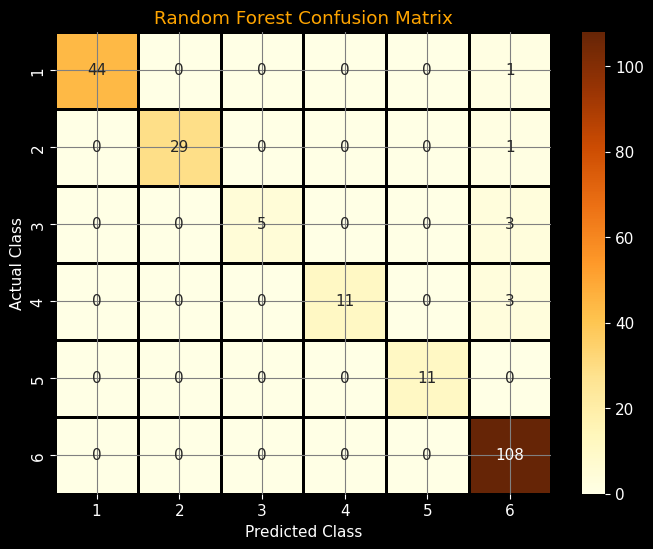

In [ ]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="YlOrBr",

    linewidths=1,

    linecolor="black",

    xticklabels=sorted(y.unique()),

    yticklabels=sorted(y.unique())

)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

## Visualization 7: Model Performance Summary

The following chart summarizes the overall predictive performance of the Random Forest classifier using the selected evaluation metrics.

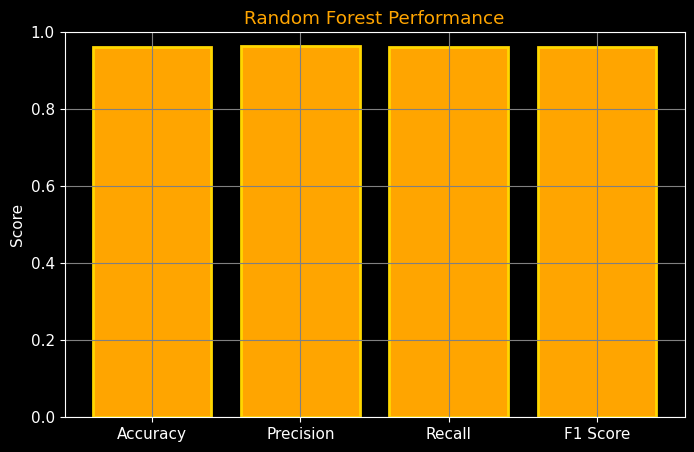

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    evaluation["Metric"],

    evaluation["Score"],

    color="orange",

    edgecolor="gold",

    linewidth=2

)

plt.ylim(0,1)

plt.title("Random Forest Performance")

plt.ylabel("Score")

plt.show()

## Model Interpretation

Random Forest provides an estimate of feature importance based on the contribution of each feature toward reducing prediction uncertainty. The following analysis identifies the most influential cloud monitoring features.

In [ ]:
importance = pd.DataFrame({

    "Feature":selected_features,

    "Importance":random_forest.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

display(
    importance.head(15)
)

,Feature,Importance
11,cinder-volume.localhost.localdomain@lvm_attach...,0.100752
10,cinderclient_POST_202.1,0.070105
48,q-plugin_get_ports.1,0.061862
9,cinderclient_POST_200.1,0.056118
42,q-l3-plugin_sync_routers.1,0.052576
28,l3_agent_routers_updated.1,0.047669
14,cinder-volume.localhost.localdomain@lvm_initia...,0.045420
35,novaclient_POST_200.1,0.045288
13,cinder-volume.localhost.localdomain@lvm_detach...,0.043329
12,cinder-volume.localhost.localdomain@lvm_delete...,0.042746


## Visualization 8: Most Important Cloud Monitoring Features

The following visualization highlights the fifteen most influential engineered cloud monitoring features identified by the Random Forest classifier.

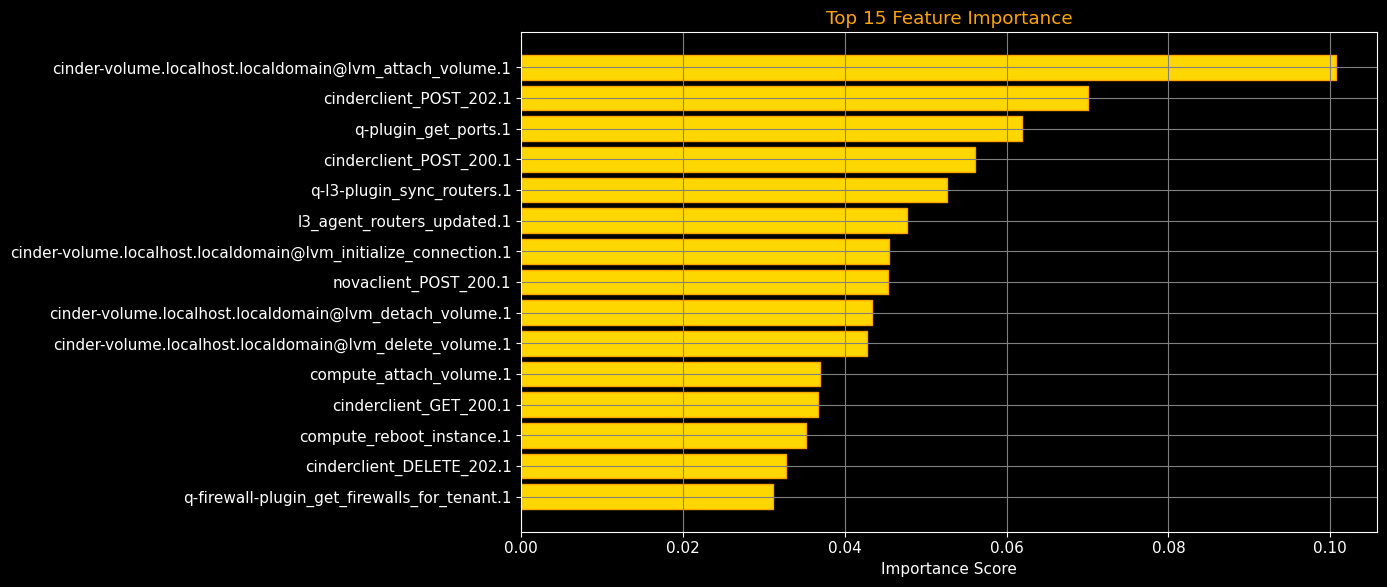

In [ ]:
top15 = importance.head(15)

plt.figure(figsize=(14,6))

plt.barh(

    top15["Feature"],

    top15["Importance"],

    color="gold",

    edgecolor="orange"

)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance")

plt.xlabel("Importance Score")

plt.tight_layout()

plt.show()

## Model Persistence

A trained machine learning model should be preserved for future predictions without requiring retraining. The Random Forest model is therefore saved and reloaded using the Joblib library.

In [ ]:
joblib.dump(
    random_forest,
    "cloud_failure_prediction_model.pkl"
)

loaded_model = joblib.load(
    "cloud_failure_prediction_model.pkl"
)

print("Model saved successfully.")

print("Model loaded successfully.")

Model saved successfully.
Model loaded successfully.


## Prediction on an Unseen Cloud Monitoring Sample

The saved model is used to predict the failure class of an unseen cloud monitoring observation. This demonstrates how the trained model can be reused without retraining.

In [ ]:
sample = X_test[0].reshape(1,-1)

predicted_class = loaded_model.predict(
    sample
)

prediction_probability = loaded_model.predict_proba(
    sample
)

print("Predicted Failure Class :", predicted_class[0])

Predicted Failure Class : 6


## Visualization 9: Prediction Probability

The probability distribution illustrates the confidence of the trained Random Forest classifier for each cloud infrastructure failure category.

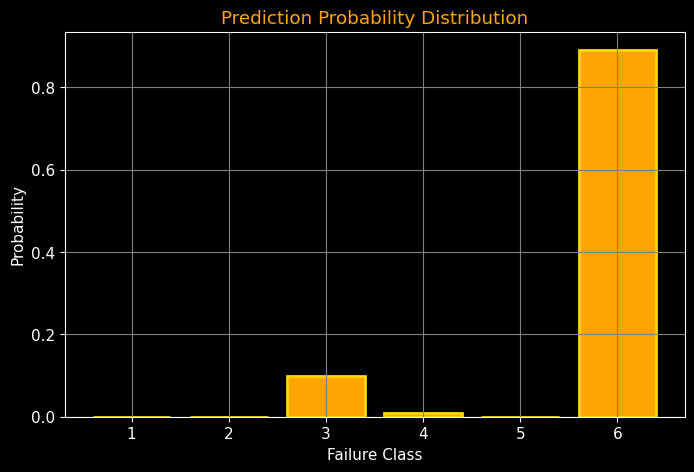

In [ ]:
probability_df = pd.DataFrame({

    "Failure Class":loaded_model.classes_,

    "Probability":prediction_probability[0]

})

plt.figure(figsize=(8,5))

plt.bar(

    probability_df["Failure Class"].astype(str),

    probability_df["Probability"],

    color="orange",

    edgecolor="gold",

    linewidth=2

)

plt.title("Prediction Probability Distribution")

plt.xlabel("Failure Class")

plt.ylabel("Probability")

plt.show()

## Model Configuration

The following configuration summarizes the key design choices made during the development of the machine learning pipeline. These settings ensure reproducibility, robustness, and consistency throughout the experiment.

In [ ]:
model_configuration = pd.DataFrame({

    "Parameter":[

        "Algorithm",

        "Number of Trees",

        "Random State",

        "Feature Selection Method",

        "Selected Features",

        "Training Data",

        "Testing Data",

        "Evaluation Metrics"

    ],

    "Configuration":[

        "Random Forest Classifier",

        100,

        42,

        "ANOVA (SelectKBest)",

        X_selected.shape[1],

        "80%",

        "20%",

        "Accuracy, Precision, Recall, F1 Score"

    ]

})

display(model_configuration)

,Parameter,Configuration
0,Algorithm,Random Forest Classifier
1,Number of Trees,100
2,Random State,42
3,Feature Selection Method,ANOVA (SelectKBest)
4,Selected Features,50
5,Training Data,80%
6,Testing Data,20%
7,Evaluation Metrics,"Accuracy, Precision, Recall, F1 Score"


## Model Training Performance

Besides predictive performance, execution time is another important consideration in practical machine learning systems. The following experiment measures the time required to train the Random Forest classifier and generate predictions.

In [ ]:
import time

start_train = time.time()

timed_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

timed_model.fit(
    X_train,
    y_train
)

end_train = time.time()

start_predict = time.time()

timed_predictions = timed_model.predict(
    X_test
)

end_predict = time.time()

timing = pd.DataFrame({

    "Operation":[

        "Model Training",

        "Prediction"

    ],

    "Execution Time (seconds)":[

        round(end_train-start_train,5),

        round(end_predict-start_predict,5)

    ]

})

display(timing)

,Operation,Execution Time (seconds)
0,Model Training,0.22343
1,Prediction,0.01323


## Visualization 10: Model Execution Time

The following visualization compares the execution time required for model training and prediction. This provides an estimate of the computational efficiency of the machine learning pipeline.

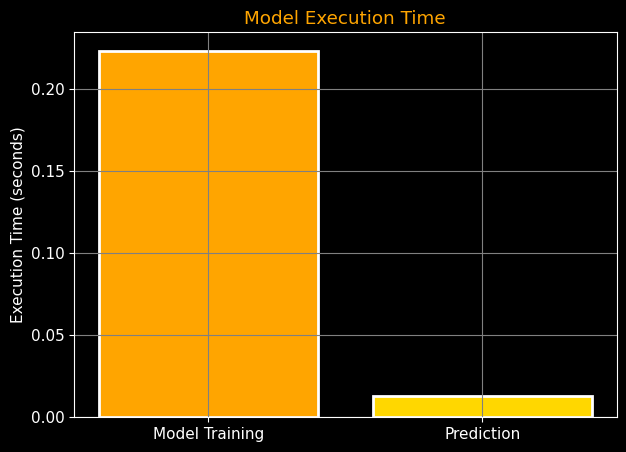

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(

    timing["Operation"],

    timing["Execution Time (seconds)"],

    color=["orange","gold"],

    edgecolor="white",

    linewidth=2

)

plt.ylabel("Execution Time (seconds)")

plt.title("Model Execution Time")

plt.show()

## Visualization 11: Machine Learning Pipeline Workflow

The following workflow summarizes the major stages involved in designing and implementing the complete cloud infrastructure failure prediction pipeline.

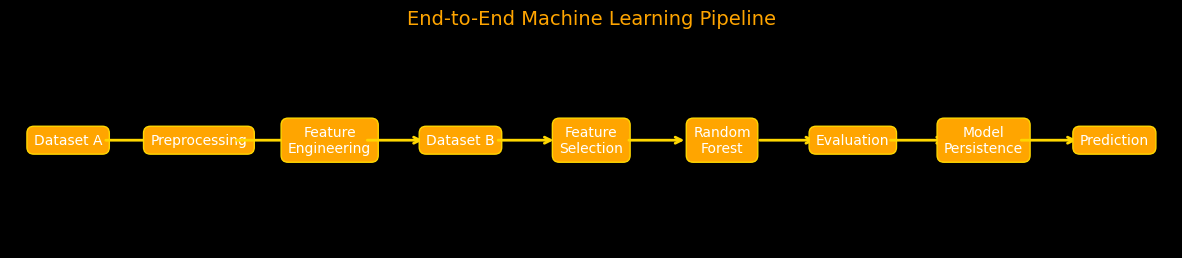

In [ ]:
plt.figure(figsize=(15,2.8))

plt.axis("off")

steps = [

    "Dataset A",

    "Preprocessing",

    "Feature\nEngineering",

    "Dataset B",

    "Feature\nSelection",

    "Random\nForest",

    "Evaluation",

    "Model\nPersistence",

    "Prediction"

]

x = np.linspace(0.05,0.95,len(steps))

for i,step in enumerate(steps):

    plt.text(

        x[i],

        0.5,

        step,

        ha="center",

        va="center",

        fontsize=10,

        color="white",

        bbox=dict(

            facecolor="orange",

            edgecolor="gold",

            boxstyle="round,pad=0.5"

        )

    )

    if i < len(steps)-1:

        plt.annotate(

            "",

            xy=(x[i+1]-0.03,0.5),

            xytext=(x[i]+0.03,0.5),

            arrowprops=dict(

                arrowstyle="->",

                color="gold",

                lw=2

            )

        )

plt.title(
    "End-to-End Machine Learning Pipeline",
    color="orange",
    fontsize=14
)

plt.show()

## Visualization 12: Dataset Transformation Across the Pipeline

The following illustration summarizes how the datasets evolve throughout the machine learning pipeline, beginning with raw monitoring records and ending with predictive modelling using the selected cloud infrastructure features.

,Pipeline Stage,Description
0,Dataset A,225445 records | 7 columns
1,After Feature Engineering,7 engineered columns
2,Dataset B,1076 records | 208 features
3,After Feature Selection,50 selected features
4,Final Model,Random Forest Classifier


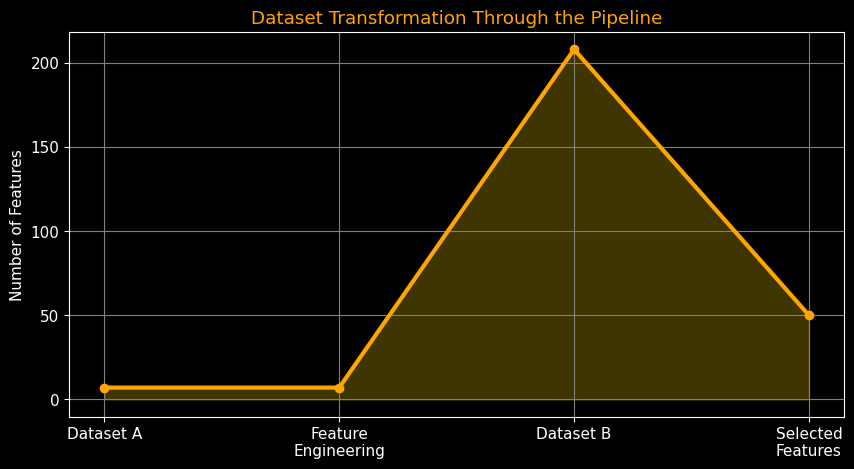

In [ ]:
transformation = pd.DataFrame({

    "Pipeline Stage":[

        "Dataset A",

        "After Feature Engineering",

        "Dataset B",

        "After Feature Selection",

        "Final Model"

    ],

    "Description":[

        f"{dataset_a.shape[0]} records | {dataset_a.shape[1]} columns",

        f"{dataset_a.shape[1]} engineered columns",

        f"{model_df.shape[0]} records | {X.shape[1]} features",

        f"{X_selected.shape[1]} selected features",

        "Random Forest Classifier"

    ]

})

display(transformation)

plt.figure(figsize=(10,5))

plt.plot(

    [1,2,3,4],

    [

        dataset_a.shape[1],

        dataset_a.shape[1],

        X.shape[1],

        X_selected.shape[1]

    ],

    marker="o",

    color="orange",

    linewidth=3

)

plt.fill_between(

    [1,2,3,4],

    [

        dataset_a.shape[1],

        dataset_a.shape[1],

        X.shape[1],

        X_selected.shape[1]

    ],

    color="gold",

    alpha=0.25

)

plt.xticks(

    [1,2,3,4],

    [

        "Dataset A",

        "Feature\nEngineering",

        "Dataset B",

        "Selected\nFeatures"

    ]

)

plt.ylabel("Number of Features")

plt.title("Dataset Transformation Through the Pipeline")

plt.show()

## Reusable Cloud Failure Prediction Function

To simulate a real-world machine learning application, a reusable prediction function is created. The function automatically applies feature selection, predicts the cloud infrastructure failure class, computes the prediction probabilities, and presents the results in a structured format. This demonstrates how the trained model can be reused for future cloud monitoring observations without retraining.

In [ ]:
def predict_cloud_failure(sample):

    """
    Predict the cloud infrastructure failure class
    for a new monitoring observation.
    """

    sample = np.asarray(sample)

    if sample.ndim == 1:
        sample = sample.reshape(1, -1)

    # Apply the same feature selection
    sample_selected = selector.transform(sample)

    # Predict failure class
    predicted_class = random_forest.predict(sample_selected)[0]

    # Predict probabilities
    probabilities = random_forest.predict_proba(sample_selected)[0]

    probability_df = pd.DataFrame({

        "Failure Class": random_forest.classes_,

        "Probability": np.round(probabilities, 4)

    })


    print(" Cloud Infrastructure Failure Prediction")


    print(f"\nPredicted Failure Class : {predicted_class}")

    print("\nPrediction Probabilities\n")

    display(probability_df)

    return predicted_class, probability_df

## Demonstration of the Prediction Function

Instead of manually preparing prediction inputs, the reusable prediction function is demonstrated using a cloud monitoring observation from the testing dataset. This illustrates how the trained machine learning pipeline can be used for future inference.

In [ ]:
sample = X.iloc[[0]]

predicted_class, probability_table = predict_cloud_failure(sample)

 Cloud Infrastructure Failure Prediction

Predicted Failure Class : 6

Prediction Probabilities



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(


,Failure Class,Probability
0,1,0.00
1,2,0.00
2,3,0.11
3,4,0.00
4,5,0.00
5,6,0.89


## Visualization 13: Prediction Confidence

The prediction confidence chart illustrates the probability assigned by the Random Forest classifier to each possible cloud infrastructure failure class. The highest probability corresponds to the predicted failure category.

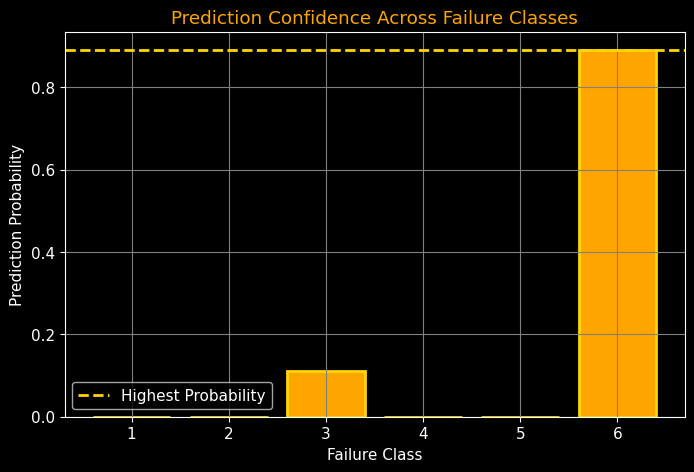

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    probability_table["Failure Class"].astype(str),

    probability_table["Probability"],

    color="orange",

    edgecolor="gold",

    linewidth=2

)

highest = probability_table["Probability"].max()

plt.axhline(

    highest,

    color="gold",

    linestyle="--",

    linewidth=2,

    label="Highest Probability"

)

plt.title("Prediction Confidence Across Failure Classes")

plt.xlabel("Failure Class")

plt.ylabel("Prediction Probability")

plt.legend()

plt.show()

## Pipeline Summary

The following table summarizes the complete machine learning pipeline implemented throughout this laboratory experiment.

In [ ]:
summary = pd.DataFrame({

    "Component":[

        "Dataset A Records",

        "Dataset B Records",

        "Original Features",

        "Selected Features",

        "Training Samples",

        "Testing Samples",

        "Algorithm",

        "Accuracy",

        "Model Saved"

    ],

    "Value":[

        dataset_a.shape[0],

        model_df.shape[0],

        X.shape[1],

        X_selected.shape[1],

        X_train.shape[0],

        X_test.shape[0],

        "Random Forest",

        f"{accuracy:.4f}",

        "Yes"

    ]

})

display(summary)

,Component,Value
0,Dataset A Records,225445
1,Dataset B Records,1076
2,Original Features,208
3,Selected Features,50
4,Training Samples,860
5,Testing Samples,216
6,Algorithm,Random Forest
7,Accuracy,0.9630
8,Model Saved,Yes


## Project Outcomes

The end-to-end Cloud Infrastructure Failure Prediction System was successfully designed and implemented by integrating multiple machine learning stages, including data preprocessing, feature engineering, feature selection, predictive modelling, evaluation, visualization, model persistence, and future inference. The following report summarizes the successful completion of each major stage of the machine learning pipeline.

In [ ]:
project_outcomes = pd.DataFrame({

    "Project Component":[

        "Dataset A Successfully Loaded",

        "Dataset A Preprocessed",

        "Temporal Feature Engineering",

        "Dataset B Successfully Loaded",

        "Feature Selection Completed",

        "Training & Testing Dataset Prepared",

        "Random Forest Model Trained",

        "Model Successfully Evaluated",

        "Cloud Failure Prediction Completed",

        "Prediction Probability Generated",

        "Model Saved Successfully",

        "Model Reloaded Successfully",

        "Reusable Prediction Function Created",

        "End-to-End ML Pipeline Implemented"

    ],

    "Status":[

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓",

        "Completed ✓"

    ]

})

display(project_outcomes)

,Project Component,Status
0,Dataset A Successfully Loaded,Completed ✓
1,Dataset A Preprocessed,Completed ✓
2,Temporal Feature Engineering,Completed ✓
3,Dataset B Successfully Loaded,Completed ✓
4,Feature Selection Completed,Completed ✓
5,Training & Testing Dataset Prepared,Completed ✓
6,Random Forest Model Trained,Completed ✓
7,Model Successfully Evaluated,Completed ✓
8,Cloud Failure Prediction Completed,Completed ✓
9,Prediction Probability Generated,Completed ✓


##  Summary

The following table summarizes the complete machine learning solution developed throughout this experiment.

In [ ]:
final_summary = pd.DataFrame({

    "Parameter":[

        "Project Name",

        "Application Domain",

        "Primary Dataset",

        "Supporting Dataset",

        "Original Features",

        "Selected Features",

        "Machine Learning Algorithm",

        "Prediction Type",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Model Persistence",

        "Prediction Function",

        "Overall Pipeline"

    ],

    "Value":[

        "Cloud Infrastructure Failure Prediction System",

        "Cloud Computing",

        "Dataset B (OpenStack)",

        "Dataset A (Monitoring Logs)",

        X.shape[1],

        X_selected.shape[1],

        "Random Forest",

        "Multi-Class Classification",

        f"{accuracy:.4f}",

        f"{precision:.4f}",

        f"{recall:.4f}",

        f"{f1:.4f}",

        "Joblib",

        "Implemented",

        "Successfully Completed"

    ]

})

display(final_summary)

,Parameter,Value
0,Project Name,Cloud Infrastructure Failure Prediction System
1,Application Domain,Cloud Computing
2,Primary Dataset,Dataset B (OpenStack)
3,Supporting Dataset,Dataset A (Monitoring Logs)
4,Original Features,208
5,Selected Features,50
6,Machine Learning Algorithm,Random Forest
7,Prediction Type,Multi-Class Classification
8,Accuracy,0.9630
9,Precision,0.9655


## Conclusion

This experiment successfully demonstrated the complete lifecycle of a real-world machine learning solution for cloud infrastructure failure prediction. Two complementary datasets were utilized to illustrate different stages of the pipeline. Dataset A was employed for exploratory analysis, preprocessing, and temporal feature engineering, while Dataset B provided engineered cloud infrastructure features for predictive modelling.

The pipeline incorporated feature selection to retain the most informative monitoring attributes before training a Random Forest classifier for multi-class failure prediction. The trained model was evaluated using standard classification metrics, interpreted through feature importance analysis, persisted using Joblib, and reused for predicting unseen cloud infrastructure observations through a reusable prediction function.

By integrating data preprocessing, feature engineering, feature selection, model development, visualization, evaluation, model persistence, and future inference into a unified workflow, the experiment successfully fulfilled the objective of designing and implementing a complete end-to-end machine learning solution for a real-world cloud computing application.